# Thesis — Step 3: Vulnerability Profiles (revised)

**Question answered here:** what profiles emerge among the characteristics that carried predictive signal in step 2?


**The clustering method has changed.** Most of the structural predictors are categorical, so k-means is not appropriate: it computes Euclidean distances on dummy columns, which has no clear meaning for unordered categories. This notebook uses Gower distance, which handles mixed data directly by comparing numeric variables on their range and categorical variables by whether they match, combined with PAM, which chooses actual households as cluster centres.

**The variables are fixed by the rule set in notebook 02**, not chosen after seeing the results, and the number of clusters is chosen by a criterion that does not use the outcome. Food consumption enters only afterwards, to test whether the profiles differ.

**How to read the result.** Because the clustering uses only variables selected for being predictive of food consumption, the profiles describe structure within that predictive subspace. They are not a general classification of vulnerability, and the analysis remains descriptive.


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score
from scipy.stats import chi2_contingency, f_oneway

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 220)
RANDOM_STATE = 42
print('ready')

ready


## 2. Load the data and the pre-specified variables

The continuous food consumption score is attached for validation only. Neither it nor the food consumption group takes any part in forming the clusters.

In [2]:
df = pd.read_csv('clean_R8.csv')
df['fcg'] = df['fcg'].replace({'Moderate': 'Borderline'})

raw = pd.read_excel('anon_dfAFG_R8.xlsx')
df['fcs'] = raw['fcs'].values

cluster_vars = pd.read_csv('top_variables.csv')['variable'].tolist()
print('variables fixed by the rule in notebook 02:')
for v in cluster_vars:
    print('   ', v)

cat_cols = [c for c in cluster_vars if not pd.api.types.is_numeric_dtype(df[c])]
num_cols = [c for c in cluster_vars if c not in cat_cols]
print()
print(len(num_cols), 'numeric,', len(cat_cols), 'categorical')

variables fixed by the rule in notebook 02:
    ls_main
    tot_income
    income_sec
    hh_wealth_water
    income_main
    crp_landsize_ha
    n_shocks
    income_main_comp
    crp_irrig_source
    hh_wealth_light
    need_crop_inputs
    need_env_infra_rehab

3 numeric, 9 categorical


## 3. Gower distance

For each pair of households, numeric variables contribute the absolute difference scaled by the range of that variable, and categorical variables contribute zero if the two households share the category and one if they do not. The average across variables is the distance, which always lies between 0 and 1.



In [3]:
SAMPLE_SIZE = None   

data = df if SAMPLE_SIZE is None else df.sample(SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)

numeric_scaled = MinMaxScaler().fit_transform(data[num_cols].astype(float)).astype(np.float32)
n = len(data)
D = np.zeros((n, n), dtype=np.float32)

for j in range(numeric_scaled.shape[1]):
    D += np.abs(numeric_scaled[:, [j]] - numeric_scaled[:, j][None, :])

for c in cat_cols:
    values = np.asarray(data[c].astype(str).tolist(), dtype=object)
    D += (values[:, None] != values[None, :]).astype(np.float32)

D /= (len(num_cols) + len(cat_cols))
print('distance matrix:', D.shape, '|', round(D.nbytes / 1e6), 'MB | mean distance', round(float(D.mean()), 3))

distance matrix: (9494, 9494) | 361 MB | mean distance 0.52


## 4. PAM

PAM, also called k-medoids, picks actual households as cluster centres and assigns every other household to the nearest one. Unlike k-means it never computes an average of categories, which is what makes it suitable here.

The algorithm is run from several random starts and the solution with the lowest total distance is kept.

In [4]:
def pam(D, k, seed=0, max_iter=100):
    rng = np.random.default_rng(seed)
    medoids = rng.choice(len(D), k, replace=False)
    for _ in range(max_iter):
        labels = D[:, medoids].argmin(1)
        updated = medoids.copy()
        for c in range(k):
            members = np.where(labels == c)[0]
            if len(members) == 0:
                continue
            updated[c] = members[D[np.ix_(members, members)].sum(0).argmin()]
        if (updated == medoids).all():
            break
        medoids = updated
    labels = D[:, medoids].argmin(1)
    cost = D[np.arange(len(D)), medoids[labels]].sum()
    return labels, medoids, cost

def best_pam(D, k, restarts=5):
    best = None
    for s in range(restarts):
        labels, medoids, cost = pam(D, k, seed=s)
        if best is None or cost < best[2]:
            best = (labels, medoids, cost)
    return best

print('defined')

defined


## 5. Choosing the number of clusters

The silhouette is computed on the Gower distance itself and measures how much closer households are to their own cluster than to the nearest other one. It does not use food consumption in any way, so the number of clusters is not chosen to make the outcome look separated.

   total distance  silhouette
k                            
2            3296       0.182
3            2984       0.191
4            2776       0.192
5            2705       0.175
6            2643       0.147
7            2488       0.156


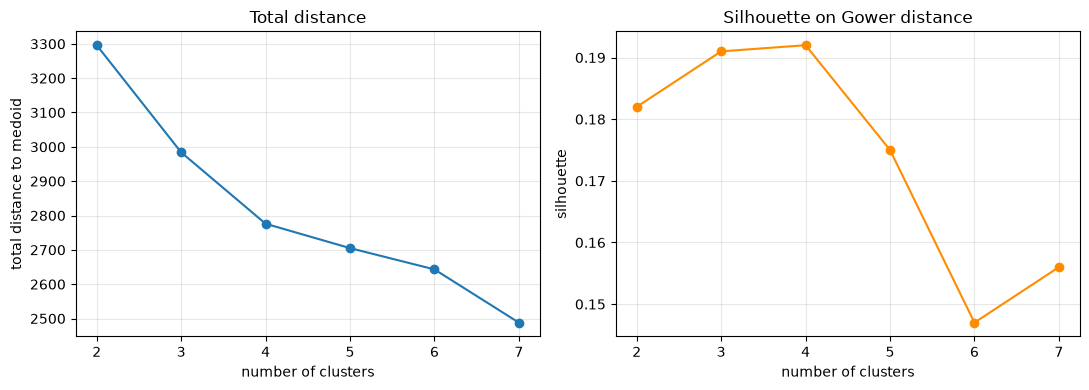

In [5]:
rng = np.random.default_rng(0)
sample_idx = rng.choice(n, min(3000, n), replace=False)

diagnostics = []
for k in range(2, 8):
    labels, medoids, cost = best_pam(D, k)
    sil = silhouette_score(D[np.ix_(sample_idx, sample_idx)], labels[sample_idx], metric='precomputed')
    diagnostics.append({'k': k, 'total distance': round(float(cost)), 'silhouette': round(float(sil), 3)})

diag = pd.DataFrame(diagnostics).set_index('k')
print(diag)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(diag.index, diag['total distance'], 'o-')
axes[0].set_xlabel('number of clusters'); axes[0].set_ylabel('total distance to medoid')
axes[1].plot(diag.index, diag['silhouette'], 'o-', color='darkorange')
axes[1].set_xlabel('number of clusters'); axes[1].set_ylabel('silhouette')
for a, t in zip(axes, ['Total distance', 'Silhouette on Gower distance']):
    a.set_title(t); a.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_cluster_selection.png', dpi=200)
plt.show()

## 6. Fit the chosen solution


In [6]:
K = int(diag['silhouette'].idxmax())
print('silhouette selects k =', K)

labels, medoids, cost = best_pam(D, K, restarts=10)
data['profile'] = labels
print(data['profile'].value_counts().sort_index().to_dict())

silhouette selects k = 4
{0: 1926, 1: 4062, 2: 2390, 3: 1116}


## 7. Do the profiles differ in food consumption?

The validation step, and the first point at which the outcome is used. The chi squared test works on the three categories, the analysis of variance on the continuous score.

In [7]:
counts = pd.crosstab(data['profile'], data['fcg'])
shares = pd.crosstab(data['profile'], data['fcg'], normalize='index') * 100

summary = shares.round(1)
summary['households'] = data['profile'].value_counts().sort_index()
summary['mean FCS'] = data.groupby('profile')['fcs'].mean().round(1)
print(summary)

chi2, p_chi, dof, _ = chi2_contingency(counts)
F, p_anova = f_oneway(*[g['fcs'].values for _, g in data.groupby('profile')])
print()
print('chi squared', round(chi2, 1), ', p value', format(p_chi, '.2e'))
print('ANOVA F', round(F, 1), ', p value', format(p_anova, '.2e'))
print()
print('spread in the Poor share across profiles:',
      round(shares['Poor'].max() - shares['Poor'].min(), 1), 'percentage points')
summary.to_csv('results_profiles.csv')

fcg      Acceptable  Borderline  Poor  households  mean FCS
profile                                                    
0              28.8        46.4  24.8        1926      37.2
1              21.0        39.8  39.2        4062      33.1
2              19.5        50.1  30.4        2390      33.9
3              10.4        36.6  53.0        1116      28.8

chi squared 361.5 , p value 5.23e-75
ANOVA F 108.0 , p value 9.55e-69

spread in the Poor share across profiles: 28.2 percentage points


## 8. What is each profile?

First the numeric averages, then the categories most over represented in each profile compared with the sample as a whole.

In [8]:
numeric_profile = data.groupby('profile')[num_cols + ['fcs']].mean().round(2)
numeric_profile['households'] = data['profile'].value_counts().sort_index()
print(numeric_profile)

         tot_income  crp_landsize_ha  n_shocks    fcs  households
profile                                                          
0          13018.24             0.58      3.65  37.22        1926
1          16477.42             0.60      4.27  33.12        4062
2          12025.46             0.55      3.23  33.86        2390
3           8370.33             0.61      3.03  28.79        1116


In [9]:
for p in sorted(data['profile'].unique()):
    sub = data[data['profile'] == p]
    rows = []
    for col in cat_cols:
        overall = data[col].value_counts(normalize=True)
        inside = sub[col].value_counts(normalize=True)
        for value, share in inside.items():
            if share > 0.15:
                rows.append({'variable': col, 'value': str(value)[:44],
                             'in profile %': share * 100,
                             'in sample %': overall.get(value, 0) * 100,
                             'difference': (share - overall.get(value, 0)) * 100})
    top = pd.DataFrame(rows).sort_values('difference', ascending=False).head(6)
    print()
    print('PROFILE', p, '|', len(sub), 'households |',
          round((sub['fcg'] == 'Poor').mean() * 100, 1), 'percent Poor')
    print(top.to_string(index=False, float_format=lambda v: f'{v:.1f}'))


PROFILE 0 | 1926 households | 24.8 percent Poor
        variable                                        value  in profile %  in sample %  difference
     income_main Production and sale of livestock and livesto          60.4         13.8        46.6
crp_irrig_source                               Not applicable          65.8         24.5        41.3
need_crop_inputs                                           No          81.4         41.7        39.7
         ls_main       Cattle (cow, beef, veal, yak, buffalo)          60.1         21.7        38.3
         ls_main                                        Sheep          22.2          9.5        12.8
         ls_main                                         Goat          16.7          6.4        10.3

PROFILE 1 | 4062 households | 39.2 percent Poor
            variable                                        value  in profile %  in sample %  difference
    need_crop_inputs                                          Yes          99.7         46

## 9. Where are the profiles located?

Province was deliberately left out of the clustering, so this is a result rather than something built in.

In [10]:
geo = pd.crosstab(data['adm1_name'], data['profile'], normalize='index') * 100
geo['dominant profile'] = geo.iloc[:, :K].idxmax(axis=1)
geo['share of that profile'] = geo.iloc[:, :K].max(axis=1).round(1)
geo['Poor %'] = data.groupby('adm1_name')['fcg'].apply(lambda s: (s == 'Poor').mean() * 100).round(1)
print(geo[['dominant profile', 'share of that profile', 'Poor %']]
      .sort_values('Poor %', ascending=False).to_string())

profile         dominant profile  share of that profile  Poor %
adm1_name                                                      
Ghor                           2                   67.4    74.3
Balkh                          1                   68.5    73.6
Bamyan                         1                   40.7    67.5
Daykundi                       2                   60.1    65.3
Laghman                        1                   68.6    65.0
Khost                          0                   40.4    61.1
Kunduz                         1                   84.8    59.1
Not applicable                 3                   38.5    53.8
Samangan                       1                   47.2    48.6
Nangarhar                      1                   58.5    46.2
Paktika                        1                   66.0    46.2
Baghlan                        3                   38.2    44.6
Paktya                         1                   64.2    44.4
Nimroz                         3        

## 10. A result that does not depend on the clustering

The clearest single distinction in the data needs no clustering at all, and is therefore immune to any objection about the choice of method. It is reported on its own in the results chapter.

In [11]:
no_income = df['income_main'].astype(str).str.startswith('No income source')

print('households reporting no income source in the last three months:',
      int(no_income.sum()), f'({no_income.mean()*100:.1f} percent of the sample)')
print()
comparison = pd.DataFrame({
    'no income source': df.loc[no_income, 'fcg'].value_counts(normalize=True) * 100,
    'rest of the sample': df.loc[~no_income, 'fcg'].value_counts(normalize=True) * 100,
}).round(1)
print(comparison)

table = pd.crosstab(no_income, df['fcg'])
chi2, p, dof, _ = chi2_contingency(table)
print()
print('chi squared', round(chi2, 1), ', p value', format(p, '.2e'))
print('mean FCS:', round(df.loc[no_income, 'fcs'].mean(), 1),
      'against', round(df.loc[~no_income, 'fcs'].mean(), 1))
comparison.to_csv('results_no_income.csv')

households reporting no income source in the last three months: 1093 (11.5 percent of the sample)

            no income source  rest of the sample
fcg                                             
Acceptable              10.5                22.3
Borderline              35.9                44.3
Poor                    53.6                33.4

chi squared 191.5 , p value 2.60e-42
mean FCS: 28.4 against 34.3


## 11. Figures

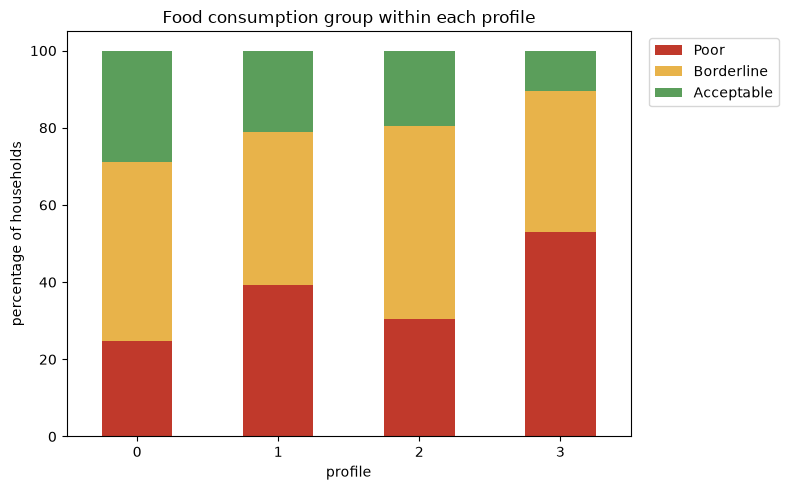

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
shares[['Poor', 'Borderline', 'Acceptable']].plot(
    kind='bar', stacked=True, ax=ax, color=['#c0392b', '#e8b34a', '#5b9e5b'])
ax.set_xlabel('profile'); ax.set_ylabel('percentage of households')
ax.set_title('Food consumption group within each profile')
ax.legend(title='', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0); plt.tight_layout()
plt.savefig('fig_profiles_fcg.png', dpi=200)
plt.show()

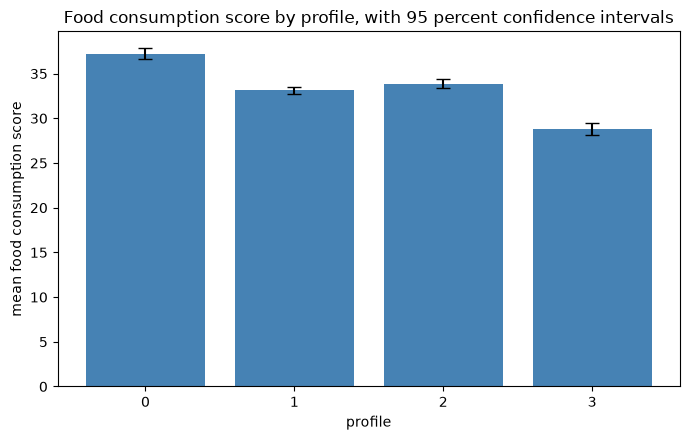

In [13]:
fig, ax = plt.subplots(figsize=(7, 4.5))
means = data.groupby('profile')['fcs'].mean()
errors = data.groupby('profile')['fcs'].sem() * 1.96
ax.bar(means.index.astype(str), means.values, yerr=errors.values, capsize=5, color='steelblue')
ax.set_xlabel('profile'); ax.set_ylabel('mean food consumption score')
ax.set_title('Food consumption score by profile, with 95 percent confidence intervals')
plt.tight_layout()
plt.savefig('fig_profiles_fcs.png', dpi=200)
plt.show()

## 12. Naming the profiles


In [15]:
profile_names = {0: 'Livestock-based households',
                 1: 'Crop farmers reporting input needs',
                 2: 'Crop farmers without reported input needs',
                 3: 'Non-agricultural households'}

for p, name in profile_names.items():
    sub = data[data['profile'] == p]
    print(p, '|', name, '|', len(sub), 'households |',
          round((sub['fcg'] == 'Poor').mean() * 100, 1), 'percent Poor |',
          'mean income', round(sub['tot_income'].mean()) if 'tot_income' in sub.columns else '')

0 | Livestock-based households | 1926 households | 24.8 percent Poor | mean income 13018
1 | Crop farmers reporting input needs | 4062 households | 39.2 percent Poor | mean income 16477
2 | Crop farmers without reported input needs | 2390 households | 30.4 percent Poor | mean income 12025
3 | Non-agricultural households | 1116 households | 53.0 percent Poor | mean income 8370


## 13. Robustness: does the picture depend on the number of clusters?


In [17]:
rows = []
for k in range(3, 7):
    lab, _, _ = best_pam(D, k, restarts=5)
    tmp = data.assign(p=lab)
    sh = pd.crosstab(tmp['p'], tmp['fcg'], normalize='index') * 100
    chi2, p, _, _ = chi2_contingency(pd.crosstab(tmp['p'], tmp['fcg']))
    rows.append({'k': k,
                 'Poor spread (points)': round(sh['Poor'].max() - sh['Poor'].min(), 1),
                 'chi squared p': format(p, '.1e'),
                 'smallest cluster': int(pd.Series(lab).value_counts().min())})
print(pd.DataFrame(rows).set_index('k'))

   Poor spread (points) chi squared p  smallest cluster
k                                                      
3                  27.2       2.5e-65              1175
4                  28.2       5.2e-75              1116
5                  29.3      4.6e-102               766
6                  28.0       1.4e-69               831


## 14. Weighted food consumption within each profile

The clustering describes the households interviewed, but the share of Poor households within each profile is a prevalence, so it is also reported with the survey weights. The same is done below for the comparison of households without an income source in section 10.

In [18]:
weighted_fcg = pd.crosstab(data['profile'], data['fcg'], values=data['weight_final'],
                           aggfunc='sum', normalize='index') * 100
weighted_table = weighted_fcg[['Poor', 'Borderline', 'Acceptable']].round(1)
weighted_table['unweighted Poor'] = shares['Poor'].round(1)
weighted_table['weighted mean FCS'] = data.groupby('profile').apply(
    lambda g: np.average(g['fcs'], weights=g['weight_final'])).round(1)
print(weighted_table)
print()
print('spread in the weighted Poor share across profiles:',
      round(weighted_table['Poor'].max() - weighted_table['Poor'].min(), 1), 'percentage points')

fcg      Poor  Borderline  Acceptable  unweighted Poor  weighted mean FCS
profile                                                                  
0        21.2        50.7        28.1             24.8               37.0
1        38.3        40.8        20.9             39.2               33.3
2        25.9        57.9        16.2             30.4               33.9
3        55.8        34.7         9.5             53.0               28.6

spread in the weighted Poor share across profiles: 34.6 percentage points


In [19]:
w_no = df.loc[no_income, 'weight_final']
w_rest = df.loc[~no_income, 'weight_final']
weighted_no_income = pd.DataFrame({
    'no income source': df[no_income].groupby('fcg')['weight_final'].sum() / w_no.sum() * 100,
    'rest of the sample': df[~no_income].groupby('fcg')['weight_final'].sum() / w_rest.sum() * 100,
}).round(1)
print(weighted_no_income)
print()
print('weighted share of households with no income source:',
      round(w_no.sum() / df['weight_final'].sum() * 100, 1), 'percent')

            no income source  rest of the sample
fcg                                             
Acceptable               9.7                20.9
Borderline              33.0                48.5
Poor                    57.3                30.5

weighted share of households with no income source: 9.7 percent


**What the result shows.** With the survey weights the order of the profiles does not change. Non-agricultural households remain the most food insecure, with 55.8 percent Poor, and livestock-based households the least, with 21.2 percent, so the gap between them widens from 28.2 to 34.6 percentage points. Households without an income source are also more clearly disadvantaged with weights: 57.3 percent are Poor, against 30.5 percent of the other households, and they represent 9.7 percent of the rural population.

## 15. Where does the advantage of the livestock profile come from?

The Food Consumption Score gives milk a weight of 4, one of the two highest weights. This section recomputes the score without the milk component, to see how much of the difference between the profiles comes from milk. It also shows how the households without an income source are spread across the profiles.

In [20]:
data['milk_days'] = raw['fcs_dairy_days'].values
data['fcs_without_milk'] = data['fcs'] - 4 * data['milk_days']
print(data.groupby('profile')[['milk_days', 'fcs', 'fcs_without_milk']].mean().round(2))

no_income_data = data['income_main'].astype(str).str.startswith('No income source')
print()
print('households with no income source in each profile:')
print(data.loc[no_income_data, 'profile'].value_counts().sort_index().to_dict())

         milk_days    fcs  fcs_without_milk
profile                                    
0             2.67  37.22             26.53
1             1.64  33.12             26.56
2             1.70  33.86             27.04
3             1.10  28.79             24.38

households with no income source in each profile:
{0: 202, 1: 242, 2: 292, 3: 357}


**What the result shows.** Livestock-based households consume dairy products on 2.7 days a week, against 1.6 and 1.7 days in the two crop farming profiles. Without the milk component the first three profiles have practically the same score, 26.5, 26.6 and 27.0. The advantage of the livestock profile therefore comes almost entirely from milk, which these households can obtain from their own animals, and not from higher income, since this profile earns less than the crop farmers reporting input needs. Households without an income source are found in all four profiles, so their disadvantage is a separate result and not simply a feature of the non-agricultural profile.